In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

# Generate dataset
X, y = make_classification(
    n_samples=100,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=2,
    class_sep=0.7,
    flip_y=0.12,
    random_state=10
)

# Create DataFrame
df = pd.DataFrame(X, columns=["Feature1", "Feature2"])
df["Target"] = y

# Display first 5 rows
print(df.head())

   Feature1  Feature2  Target
0 -0.687180  0.930204       1
1 -0.991875 -0.007610       0
2 -0.079049  1.180715       1
3 -0.901542  0.739489       1
4  0.522986 -0.599896       0


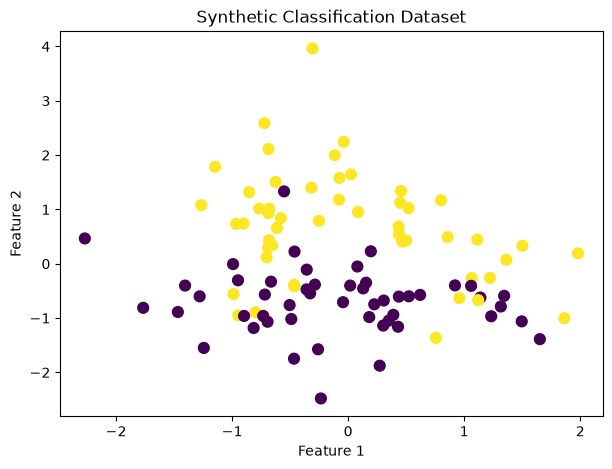

In [5]:
plt.figure(figsize=(7,5))

plt.scatter(
    df["Feature1"],
    df["Feature2"],
    c=df["Target"],
    cmap="viridis",
    s=60
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Synthetic Classification Dataset")
plt.show()

In [6]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [7]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [19]:
model = Sequential()

model.add(Dense(10,activation='tanh',input_dim=2))
model.add(Dense(1,activation='tanh'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41 (164.00 B)

 Trainable params: 41 (164.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
# Set parameters to 0
model.get_weights()

[array([[ 0.21664238, -0.51925576,  0.05980283,  0.21412706,  0.5886691 ,
         -0.3293643 ,  0.2792871 ,  0.1876769 ,  0.35013932,  0.5811648 ],
        [ 0.08956343,  0.13194156,  0.20072776, -0.30977967, -0.31153095,
          0.03721786, -0.65628254, -0.3855936 ,  0.62108475,  0.06482625]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.13335037],
        [-0.64964247],
        [ 0.6555503 ],
        [ 0.2180363 ],
        [ 0.6840846 ],
        [-0.20381379],
        [-0.14064145],
        [ 0.07751948],
        [ 0.05069256],
        [ 0.42663008]], dtype=float32),
 array([0.], dtype=float32)]

In [21]:
initial_weights = model.get_weights()

In [22]:
initial_weights[0] = np.zeros(model.get_weights()[0].shape)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.zeros(model.get_weights()[2].shape)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)

In [23]:
model.set_weights(initial_weights)

In [24]:
model.get_weights()

[array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]], dtype=float32),
 array([0.], dtype=float32)]

In [25]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [26]:
history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.4875 - loss: 8.2605 - val_accuracy: 0.5500 - val_loss: 7.2531
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4875 - loss: 8.2605 - val_accuracy: 0.5500 - val_loss: 7.2531
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4875 - loss: 8.2605 - val_accuracy: 0.5500 - val_loss: 7.2531
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4875 - loss: 8.2605 - val_accuracy: 0.5500 - val_loss: 7.2531
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4875 - loss: 8.2605 - val_accuracy: 0.5500 - val_loss: 7.2531
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4875 - loss: 8.2605 - val_accuracy: 0.5500 - val_loss: 7.2531
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4875 - loss: 8.2605 - val_accuracy: 0.5500 - val_loss: 7.2531
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4875 - loss: 8.2605 - val_accuracy: 0.5500 - val_loss:

In [27]:
model.get_weights()

[array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]], dtype=float32),
 array([0.], dtype=float32)]

<Axes: >

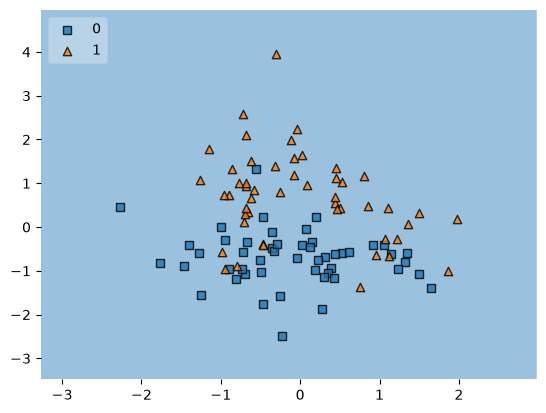

In [28]:
class KerasWrapper:
    def __init__(self, model):
        self.model = model

    def predict(self, X):
        pred = self.model.predict(X, verbose=0)
        return (pred > 0.5).astype(int).ravel()

wrapped_model = KerasWrapper(model)

plot_decision_regions(
    X,
    y,
    clf=wrapped_model,
    legend=2
)